In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))
sys.path.insert(0, str(Path('..') / 'explorations'))

import matplotlib.pyplot as plt
import sinter

from generate_circuit_with_stage_map import CircuitGenerator  # type: ignore[import]
from cultiv._decoding._desaturation_sampler import CompiledDesaturationSampler
from prior_gap_estimation import PriorGapEstimator
from prior_gap_estimation_use import PriorGapEstimatorUse
from algorithm_stats import (
    dem_sample_and_pcm_gen,
    check_clustering_nullbasis_num,
    check_clustering_nullbasis_num_plot,
    check_clustering_total_nullbasis_num_per_shot,
    check_clustering_total_nullbasis_num_per_shot_plot,
    check_gap_vs_nullbasis_count,
    check_gap_vs_nullbasis_count_plot,
    check_gap_vs_logical_error_nullbasis_count,
    check_gap_vs_logical_error_nullbasis_count_plot,
    sample_gap_shots,
    check_gap_vs_logical_error_nullbasis_count_from_samples,
    check_complementary_gap_vs_out_gap_analysis_from_samples,
    check_pymatching_vs_pge_from_sample,
)
from prior_gap_estimator_cpp import PriorGapEstimatorUse as CppEst

## 1. Build the circuit

Adjust any parameter below — mirrors the parameter block in `motivation.ipynb`.

In [2]:
# --- Circuit type ---
# options: 'escape-to-big-matchable-code', 'idle-matchable-code',
#          'surface-code-memory', 'inject+cultivate',
#          'end2end-inplace-distillation', 'escape-to-big-color-code',
#          'surface-code-cnot'
circuit_type = 'end2end-inplace-distillation'

# --- Injection protocol ---
# options: 'degenerate', 'bell', 'unitary'
injection_protocol = 'unitary'

# --- Noise model ---
# options: 'circuit-level-SI1000', 'uniform-depolarizing'
noise_model    = 'uniform-depolarizing'
noise_strength = 1e-3

# --- Gateset ---
# options: 'cz', 'css'
gateset = 'css'

# --- Logical basis ---
basis = 'Y'

# --- Code distances ---
d1 = 3   # color-code distance
d2 = 15   # surface-code distance

# --- Rounds ---
r_in_escape   = 3   # cultivation / escape rounds (r_growing)
r_post_escape = 0   # post-escape rounds (r_end)

# --- Sampling ---
shots = 500

# --- DEM modification ---
# options: 'single' (one shared obs-det, matches DesaturationSampler),
#          'per_obs' (one det per observable), None (no logical check nodes)
obs_det_type = None

In [3]:
cg = CircuitGenerator.from_input_params(
    basis=basis,
    gateset=gateset,
    circuit_type=circuit_type,
    noise_model=noise_model,
    noise_strength=noise_strength,
    injection_protocol=injection_protocol,
    r_in_escape=r_in_escape,
    r_post_escape=r_post_escape,
    d1=d1,
    d2=d2,
    HasNoise=True,
)
cg.generate()

raw_dem = cg.noisy_circuit.detector_error_model()
print(f'Detectors : {raw_dem.num_detectors}')
print(f'Faults    : {raw_dem.num_errors}')

Detectors : 1027
Faults    : 18094


## 2. Modify the DEM (desaturation + optional stage 3)

In [4]:
estimator    = PriorGapEstimator.from_desaturation(raw_dem, obs_det_type='per_obs')
modified_dem = estimator.dem

print(f'Modified DEM detectors      : {modified_dem.num_detectors}')
print(f'Modified DEM faults         : {modified_dem.num_errors}')
print(f'PCM shape (checks x faults) : {estimator.PCM.H.shape}')

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)


In [5]:
# --- build compiled (desaturation decoder) ---
task = sinter.Task(
    circuit=cg.noisy_circuit,
    detector_error_model=raw_dem,
)
compiled = CompiledDesaturationSampler.from_task(task)

print(f'Modified DEM detectors      : {compiled.gap_dem.num_detectors}')
print(f'Modified DEM faults         : {compiled.gap_dem.num_errors}')

Modified DEM detectors      : 1084
Modified DEM faults         : 17284


## 3.Collect some statistics for testing

### 3.1 Collect null-space basis size distribution

#### collect the data

In [6]:
pcm, det_results = dem_sample_and_pcm_gen(modified_dem, shots=shots, decompose=False)
counter = check_clustering_nullbasis_num(pcm, det_results)

total_clusters = sum(counter.values())
print(f'Total active valid clusters over {shots} shots : {total_clusters}')
print(f'Average clusters per shot                      : {total_clusters / shots:.2f}')
print()
print('Null-basis count  |  Cluster count')
print('----------------------------------')
for k in sorted(counter):
    print(f'  {k:>14}  |  {counter[k]}')

Total active valid clusters over 500 shots : 4529
Average clusters per shot                      : 9.06

Null-basis count  |  Cluster count
----------------------------------
               0  |  4026
               1  |  106
               2  |  68
               3  |  37
               4  |  32
               5  |  17
               6  |  21
               7  |  8
               8  |  7
               9  |  15
              10  |  14
              11  |  10
              12  |  4
              13  |  18
              14  |  12
              15  |  9
              16  |  6
              17  |  7
              18  |  11
              19  |  5
              20  |  9
              21  |  7
              22  |  8
              23  |  2
              24  |  4
              25  |  4
              26  |  2
              27  |  3
              28  |  3
              29  |  4
              30  |  3
              31  |  3
              32  |  3
              33  |  4
              34  |  1
    

#### plot the data

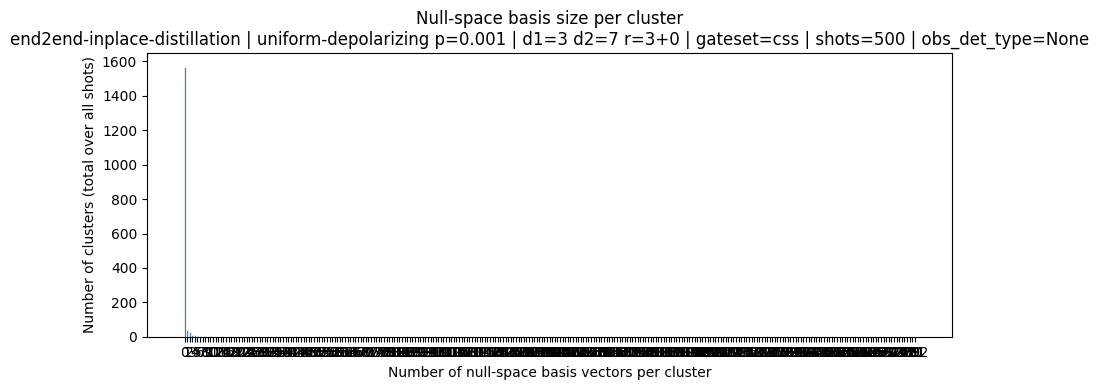

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
check_clustering_nullbasis_num_plot(
    counter,
    ax=ax,
    title=(
        f'Null-space basis size per cluster\n'
        f'{circuit_type} | {noise_model} p={noise_strength} | '
        f'd1={d1} d2={d2} r={r_in_escape}+{r_post_escape} | '
        f'gateset={gateset} | shots={shots} | obs_det_type={obs_det_type}'
    ),
)
plt.tight_layout()
plt.show()

### Total null-space basis per shot (sum / max across clusters)

#### collect the data

In [7]:
# collect_type: 'sum' or 'max'
collect_type = 'max'

per_shot = check_clustering_total_nullbasis_num_per_shot(pcm, det_results, collect_type=collect_type)

print(f'collect_type : {collect_type}')
print(f'min : {min(per_shot)},  max : {max(per_shot)},  mean : {sum(per_shot)/len(per_shot):.2f}')

collect_type : max
min : 0,  max : 282,  mean : 2.10


#### plot the data

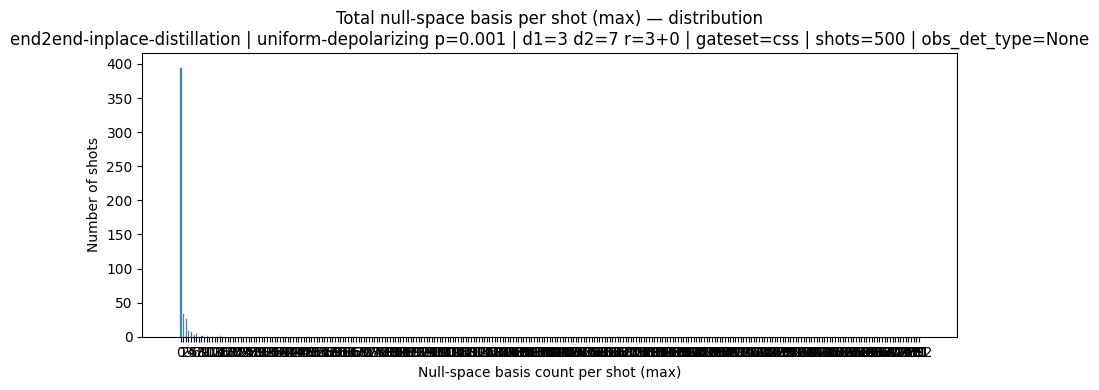

In [8]:
# plt_type: 'history' or 'distribution'
plt_type = 'distribution'

fig, ax = plt.subplots(figsize=(9, 4))
check_clustering_total_nullbasis_num_per_shot_plot(
    per_shot,
    plt_type=plt_type,
    ax=ax,
    collect_type=collect_type,
    title=(
        f'Total null-space basis per shot ({collect_type}) — {plt_type}\n'
        f'{circuit_type} | {noise_model} p={noise_strength} | '
        f'd1={d1} d2={d2} r={r_in_escape}+{r_post_escape} | '
        f'gateset={gateset} | shots={shots} | obs_det_type={obs_det_type}'
    ),
)
plt.tight_layout()
plt.show()

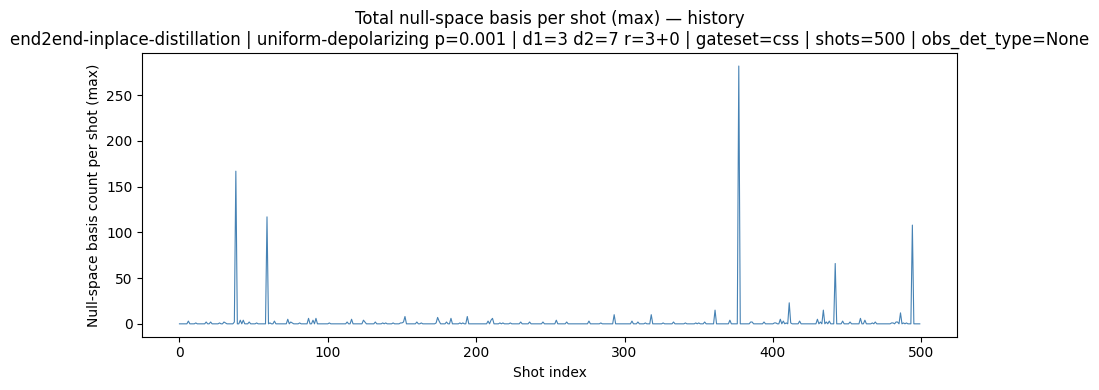

In [9]:
# plt_type: 'history' or 'distribution'
plt_type = 'history'

fig, ax = plt.subplots(figsize=(9, 4))
check_clustering_total_nullbasis_num_per_shot_plot(
    per_shot,
    plt_type=plt_type,
    ax=ax,
    collect_type=collect_type,
    title=(
        f'Total null-space basis per shot ({collect_type}) — {plt_type}\n'
        f'{circuit_type} | {noise_model} p={noise_strength} | '
        f'd1={d1} d2={d2} r={r_in_escape}+{r_post_escape} | '
        f'gateset={gateset} | shots={shots} | obs_det_type={obs_det_type}'
    ),
)
plt.tight_layout()
plt.show()

### 3.1 Collect gap v.s. logical error nullspace basis

##### Sample once

In [8]:
samples = sample_gap_shots(compiled, estimator, shots=10000)

##### basic setup, no overgrow, no multi bits per step

In [9]:
# python version
r1 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_original', # 'python' or 'cplus'
    over_grow_step=0,
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 10]
  zero basis shots   : 2472  (98.9%)
    actual flip      : 1163
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 28  (1.1%)
    actual flip      : 13
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 70]
  zero basis shots   : 2818  (96.2%)
    actual flip      : 1383
    incorrect        : 11
    plain incorrect  : 11
  nonzero basis shots: 110  (3.8%)
    actual

In [10]:
# cpp version
r1 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=0,
    bits_per_step=1
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 10]
  zero basis shots   : 2472  (98.9%)
    actual flip      : 1163
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 28  (1.1%)
    actual flip      : 13
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 70]
  zero basis shots   : 2818  (96.2%)
    actual flip      : 1383
    incorrect        : 11
    plain incorrect  : 11
  nonzero basis shots: 110  (3.8%)
    actual

##### just change bits per step

In [11]:
# python version
r2 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow_batch', # 'python' or 'cplus'
    over_grow_step=0,
    bits_per_step=3
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 6]
  zero basis shots   : 2466  (98.6%)
    actual flip      : 1155
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 34  (1.4%)
    actual flip      : 21
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 94]
  zero basis shots   : 2803  (95.7%)
    actual flip      : 1383
    incorrect        : 10
    plain incorrect  : 10
  nonzero basis shots: 125  (4.3%)
    actual 

In [ ]:
# cpp version
r2 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=0,
    bits_per_step=3
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 6]
  zero basis shots   : 2466  (98.6%)
    actual flip      : 1155
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 34  (1.4%)
    actual flip      : 21
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 94]
  zero basis shots   : 2803  (95.7%)
    actual flip      : 1383
    incorrect        : 10
    plain incorrect  : 10
  nonzero basis shots: 125  (4.3%)
    actual 

##### just change over grow step

In [13]:
# python version
r3 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow_batch', # 'python' or 'cplus'
    over_grow_step=5,
    bits_per_step=1
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 7]
  zero basis shots   : 2460  (98.4%)
    actual flip      : 1156
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 40  (1.6%)
    actual flip      : 20
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 8]
  zero basis shots   : 2723  (93.0%)
    actual flip      : 1336
    incorrect        : 6
    plain incorrect  : 6
  nonzero basis shots: 205  (7.0%)
    actual fli

In [14]:
# cpp version
r3 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=5,
    bits_per_step=1
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 7]
  zero basis shots   : 2460  (98.4%)
    actual flip      : 1156
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 40  (1.6%)
    actual flip      : 20
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 8]
  zero basis shots   : 2723  (93.0%)
    actual flip      : 1336
    incorrect        : 6
    plain incorrect  : 6
  nonzero basis shots: 205  (7.0%)
    actual fli

##### change both bits per step and overgrow step

In [15]:
# python version
r4 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow_batch', # 'python' or 'cplus'
    over_grow_step=5,
    bits_per_step=3
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 8]
  zero basis shots   : 2413  (96.5%)
    actual flip      : 1131
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 87  (3.5%)
    actual flip      : 45
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 16]
  zero basis shots   : 2618  (89.4%)
    actual flip      : 1292
    incorrect        : 7
    plain incorrect  : 7
  nonzero basis shots: 310  (10.6%)
    actual f

In [16]:
# cpp version
r4 = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=5,
    bits_per_step=3
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 8]
  zero basis shots   : 2413  (96.5%)
    actual flip      : 1131
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 87  (3.5%)
    actual flip      : 45
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 16]
  zero basis shots   : 2618  (89.4%)
    actual flip      : 1292
    incorrect        : 7
    plain incorrect  : 7
  nonzero basis shots: 310  (10.6%)
    actual f

##### Just for CPP

In [ ]:
# cpp version
result = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=15,
    bits_per_step=4
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4572
  kept shots         : 5428

=== Accepted (gap ≥ 67) ===
  shots              : 2500
  actual obs flipped : 1176  (47.0%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 9]
  zero basis shots   : 2347  (93.9%)
    actual flip      : 1095
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 153  (6.1%)
    actual flip      : 81
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2928
  actual obs flipped : 1437  (49.1%)
  incorrect decoding : 16  (0.5%)
    gap range (incorrect) : [1.04, 18.39] dB
  plain PyM incorrect: 16  (0.5%)
  basis count range  : [0, 20]
  zero basis shots   : 2459  (84.0%)
    actual flip      : 1220
    incorrect        : 3
    plain incorrect  : 3
  nonzero basis shots: 469  (16.0%)
    actual 

In [30]:
samples = sample_gap_shots(compiled, estimator, shots=100000)

In [32]:
# cpp version
result = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=0,
    bits_per_step=1
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 100000
  postsel discards   : 46125
  kept shots         : 53875

=== Accepted (gap ≥ 67) ===
  shots              : 25184
  actual obs flipped : 11889  (47.2%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 100]
  zero basis shots   : 24905  (98.9%)
    actual flip      : 11761
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 279  (1.1%)
    actual flip      : 128
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 28691
  actual obs flipped : 13959  (48.7%)
  incorrect decoding : 156  (0.5%)
    gap range (incorrect) : [0.01, 49.13] dB
  plain PyM incorrect: 156  (0.5%)
  basis count range  : [0, 132]
  zero basis shots   : 27401  (95.5%)
    actual flip      : 13308
    incorrect        : 112
    plain incorrect  : 112
  nonzero basis shots: 129

In [31]:
# cpp version
result = check_gap_vs_logical_error_nullbasis_count_from_samples(
    samples=samples,
    estimator=estimator,
    threshold=67,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus_overgrow_batch', 
    over_grow_step=15,
    bits_per_step=4
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 100000
  postsel discards   : 46125
  kept shots         : 53875

=== Accepted (gap ≥ 67) ===
  shots              : 25184
  actual obs flipped : 11889  (47.2%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 116]
  zero basis shots   : 22992  (91.3%)
    actual flip      : 10832
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 2192  (8.7%)
    actual flip      : 1057
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 28691
  actual obs flipped : 13959  (48.7%)
  incorrect decoding : 156  (0.5%)
    gap range (incorrect) : [0.01, 49.13] dB
  plain PyM incorrect: 156  (0.5%)
  basis count range  : [0, 80]
  zero basis shots   : 22423  (78.2%)
    actual flip      : 10849
    incorrect        : 46
    plain incorrect  : 46
  nonzero basis shots: 6268

##### Each time fresh shots

In [7]:
estimator    = PriorGapEstimator.from_desaturation(raw_dem, obs_det_type='per_obs')
modified_dem = estimator.dem

print(f'Modified DEM detectors      : {modified_dem.num_detectors}')
print(f'Modified DEM faults         : {modified_dem.num_errors}')
print(f'PCM shape (checks x faults) : {estimator.PCM.H.shape}')


gap_threshold = 67

result = check_gap_vs_logical_error_nullbasis_count(
    compiled,
    estimator,
    threshold=gap_threshold,
    shots=10000,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow', # 'python' or 'cplus'
    over_grow_step=0,
)

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)

check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4578
  kept shots         : 5422

=== Accepted (gap ≥ 67) ===
  shots              : 2582
  actual obs flipped : 1267  (49.1%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 44]
  zero basis shots   : 2555  (99.0%)
    actual flip      : 1253
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 27  (1.0%)
    actual flip      : 14
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2840
  actual obs flipped : 1397  (49.2%)
  incorrect decoding : 15  (0.5%)
    gap range (incorrect) : [0.25, 37.50] dB
  plain PyM incorrect: 15  (0.5%)
  basis count range  : [0, 113]
  zero basis shots   : 2718  (95.7%)
    actua

In [6]:
estimator    = PriorGapEstimator.from_desaturation(raw_dem, obs_det_type='per_obs')
modified_dem = estimator.dem

print(f'Modified DEM detectors      : {modified_dem.num_detectors}')
print(f'Modified DEM faults         : {modified_dem.num_errors}')
print(f'PCM shape (checks x faults) : {estimator.PCM.H.shape}')


gap_threshold = 67

result = check_gap_vs_logical_error_nullbasis_count(
    compiled,
    estimator,
    threshold=gap_threshold,
    shots=10000,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow_batch', # 'python' or 'cplus'
    over_grow_step=0,
    bits_per_step=1,
)

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)

check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4646
  kept shots         : 5354

=== Accepted (gap ≥ 67) ===
  shots              : 2541
  actual obs flipped : 1210  (47.6%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 101]
  zero basis shots   : 2501  (98.4%)
    actual flip      : 1188
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 40  (1.6%)
    actual flip      : 22
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2813
  actual obs flipped : 1361  (48.4%)
  incorrect decoding : 13  (0.5%)
    gap range (incorrect) : [1.04, 20.80] dB
  plain PyM incorrect: 13  (0.5%)
  basis count range  : [0, 70]
  zero basis shots   : 2705  (96.2%)
    actua

In [17]:
estimator    = PriorGapEstimator.from_desaturation(raw_dem, obs_det_type='per_obs')
modified_dem = estimator.dem

print(f'Modified DEM detectors      : {modified_dem.num_detectors}')
print(f'Modified DEM faults         : {modified_dem.num_errors}')
print(f'PCM shape (checks x faults) : {estimator.PCM.H.shape}')

gap_threshold = 67

result = check_gap_vs_logical_error_nullbasis_count(
    compiled,
    estimator,
    threshold=gap_threshold,
    shots=10000,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='python_overgrow', # 'python' or 'cplus'
    over_grow_step=50,
)

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)

check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 10000
  postsel discards   : 4602
  kept shots         : 5398

=== Accepted (gap ≥ 67) ===
  shots              : 2467
  actual obs flipped : 1192  (48.3%)
  incorrect decoding : 0  (0.0%)
    gap range (incorrect) : n/a
  plain PyM incorrect: 0  (0.0%)
  basis count range  : [0, 20]
  zero basis shots   : 2194  (88.9%)
    actual flip      : 1056
    incorrect        : 0
    plain incorrect  : 0
  nonzero basis shots: 273  (11.1%)
    actual flip      : 136
    incorrect        : 0
    plain incorrect  : 0

=== Discarded (gap < 67) ===
  shots              : 2931
  actual obs flipped : 1429  (48.8%)
  incorrect decoding : 20  (0.7%)
    gap range (incorrect) : [0.12, 20.23] dB
  plain PyM incorrect: 20  (0.7%)
  basis count range  : [0, 22]
  zero basis shots   : 2195  (74.9%)
    act

In [8]:
gap_threshold = 67

result = check_gap_vs_logical_error_nullbasis_count(
    compiled,
    estimator,
    threshold=gap_threshold,
    shots=1000000,
    collect_type='sum',       # 'max' or 'sum' across clusters
    clustering_type='cplus', # 'python' or 'cplus'
)


check_gap_vs_logical_error_nullbasis_count  [collect_type='sum']
  total shots drawn  : 1000000
  postsel discards   : 461303
  kept shots         : 538697

=== Accepted (gap ≥ 67) ===
  shots              : 251261
  actual obs flipped : 120512  (48.0%)
  incorrect decoding : 2  (0.0%)
    gap range (incorrect) : [68.76, 68.76] dB
  basis count range  : [0, 53]
  zero basis shots   : 250990  (99.9%)
    actual flip      : 120373
    incorrect        : 2
  nonzero basis shots: 271  (0.1%)
    actual flip      : 139
    incorrect        : 0

=== Discarded (gap < 67) ===
  shots              : 287436
  actual obs flipped : 139855  (48.7%)
  incorrect decoding : 1604  (0.6%)
    gap range (incorrect) : [0.02, 53.10] dB
  basis count range  : [0, 273]
  zero basis shots   : 285200  (99.2%)
    actual flip      : 138757
    incorrect        : 1508
  nonzero basis shots: 2236  (0.8%)
    actual flip      : 1098
    incorrect        : 96



### 3.2 Complementary gap v.s. Our prior estimated gap

In [14]:
samples_gap = sample_gap_shots(compiled, estimator, shots=100000)

In [15]:
est_use = PriorGapEstimatorUse.from_desaturation(
    raw_dem, obs_det_type='per_obs', clustering_type='cplus_overgrow_batch'
)

modified_dem = est_use.dem

print(f'Modified DEM detectors      : {modified_dem.num_detectors}')
print(f'Modified DEM faults         : {modified_dem.num_errors}')
print(f'PCM shape (checks x faults) : {est_use.PCM.H.shape}')

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)


In [16]:
result = check_complementary_gap_vs_out_gap_analysis_from_samples(
    samples_gap, 
    est_use, 
    threshold=67,
    gap_type='weight_diff', 
    aggregate='min',
    over_grow_step=100, 
    bits_per_step=4,
    decode=True,
    asb=False,
)


check_complementary_gap_vs_out_gap_analysis
  gap_type='weight_diff'  aggregate='min'  over_grow_step=100  bits_per_step=4
  total shots drawn  : 100000
  postsel discards   : 46133
  kept shots         : 53867

=== Accepted (complementary gap ≥ 67) ===
  shots                    : 25072
  actual obs flipped       : 11954  (47.7%)
  incorrect decoding       : 0  (0.0%)
    desat gap range        : n/a dB
    out gap range          : n/a
  plain PyM incorrect      : 0  (0.0%)
    desat gap range        : n/a dB
    out gap range          : n/a
  our method incorrect     : 96  (0.4%)
    desat gap range        : [67.293, 68.757] dB
    out gap range          : [-109.989, 20.644]
  desat gap range          : [67.017, 68.757] dB
  out gap range (finite)   : [-109.989, 195.535]
  basis count range        : [0, 71]
  zero basis shots         : 12410  (49.5%)
    incorrect              : 0
    plain incorrect        : 0
    our method incorrect   : 0
    desat gap range        : [67.017, 68.

In [11]:
result = check_complementary_gap_vs_out_gap_analysis_from_samples(
    samples_gap, 
    est_use, 
    threshold=67,
    gap_type='hamming', 
    aggregate='sum',
    over_grow_step=15, 
    bits_per_step=4,
)


check_complementary_gap_vs_out_gap_analysis
  gap_type='hamming'  aggregate='sum'  over_grow_step=15  bits_per_step=4
  total shots drawn  : 10000
  postsel discards   : 4578
  kept shots         : 5422

=== Accepted (complementary gap ≥ 67) ===
  shots                    : 2542
  actual obs flipped       : 1208  (47.5%)
  incorrect decoding       : 0  (0.0%)
  plain PyM incorrect      : 0  (0.0%)
  desat gap range          : [67.021, 68.757] dB
  desat gap (incorrect)    : n/a dB
  out gap range (finite)   : [3.000, 23.000]
  basis count range        : [0, 9]
  zero basis shots         : 2343  (92.2%)
    incorrect              : 0
    plain incorrect        : 0
    desat gap range        : [67.031, 68.757] dB
    out gap range          : n/a
  nonzero basis shots      : 199  (7.8%)
    incorrect              : 0
    plain incorrect        : 0
    desat gap range        : [67.021, 68.757] dB
    out gap range          : [3.000, 23.000]

=== Discarded (complementary gap < 67) ===
  sh

### 3.3 Complementary Gap v.s. Prior Gap Estimator

In [6]:
samples_pge = sample_gap_shots(compiled, estimator, shots=100000)

In [7]:
est_use_pge = PriorGapEstimatorUse.from_desaturation(
    raw_dem, obs_det_type='per_obs', clustering_type='cplus_overgrow_batch'
)

modified_dem_pge= est_use_pge.dem

print(f'Modified DEM detectors      : {modified_dem_pge.num_detectors}')
print(f'Modified DEM faults         : {modified_dem_pge.num_errors}')
print(f'PCM shape (checks x faults) : {est_use_pge.PCM.H.shape}')

Modified DEM detectors      : 1084
Modified DEM faults         : 17284
PCM shape (checks x faults) : (1084, 17284)


In [8]:
# Build C++ estimator from the same PCM
#    estimator.PCM is the ParityCheckMatrices built by PriorGapEstimator
cpp_est_pge = CppEst(est_use_pge.PCM)

In [18]:
result_pge = check_pymatching_vs_pge_from_sample(
    samples_pge,
    cpp_est_pge,
    pge_threshold=50,           # accept if PGE gap >= this
    comp_gap_threshold=65,      # accept if complementary gap >= this
    gap_type='weight_diff',
    aggregate='min',
    over_grow_step=15,
    bits_per_step=4,
    decode=True,
    prior_gap_estimate_type='python',
)


check_pymatching_vs_pge_from_sample
  gap_type='weight_diff'  aggregate='min'  over_grow_step=15  bits_per_step=4
  prior_gap_estimate_type='python'  decode=True
  total shots drawn : 10000
  postsel discards  : 4581
  kept shots (n)    : 5419

--- Complementary gap  (threshold=65) ---
  reject rate : 2679/5419=0.494372
  LER (desat) : 0/5419=0.000000

--- PGE gap  (threshold=50) ---
  reject rate           : 779/5419=0.143753
  LER (PyMatching dec.) : 4/5419=0.000738
  LER (PGE dec.)        : 9/5419=0.001661


In [11]:
result_pge = check_pymatching_vs_pge_from_sample(
    samples_pge,
    cpp_est_pge,
    pge_threshold=50,           # accept if PGE gap >= this
    comp_gap_threshold=65,      # accept if complementary gap >= this
    gap_type='weight_diff',
    aggregate='min',
    over_grow_step=50,
    bits_per_step=4,
    decode=True,
    prior_gap_estimate_type='cpp',
)


check_pymatching_vs_pge_from_sample
  gap_type='weight_diff'  aggregate='min'  over_grow_step=50  bits_per_step=4
  prior_gap_estimate_type='cpp'  decode=True
  total shots drawn : 100000
  postsel discards  : 46088
  kept shots (n)    : 53912

--- Baseline (PyMatching, no discard) ---
  LER : 169/53912=0.003135

--- Complementary gap  (threshold=65) ---
  reject rate : 26943/53912=0.499759
  LER (desat) : 0/53912=0.000000

--- PGE gap  (threshold=50) ---
  reject rate           : 18585/53912=0.344728
  LER (PyMatching dec.) : 13/53912=0.000241
  LER (PGE dec.)        : 30/53912=0.000556

--- Incorrect-shot discard  (n=169 plain-incorrect shots) ---
  comp gap discards incorrect : m1/n = 169/169=1.000000
  PGE gap discards incorrect  : m2/n = 156/169=0.923077
  PGE vs comp gap             : m2/m1 = 156/169=0.923077
